## 15 CLUSTERING ANALYSIS
### Understanding and Implementing K-Means and DBSCAN Algorithms
By **Mohan Sirumalla**
***

**Objective:**
The objective of this assignment is to introduce to various clustering algorithms, including K-
Means, hierarchical, and DBSCAN, and provide hands-on experience in applying these
techniques to a real-world dataset.

### Data Preprocessing:

#### 1. Preprocess the dataset to handle missing values, remove outliers, and scale the features if necessary.

In [231]:
import os
# 1. Set environment variable BEFORE importing sklearn to suppress warning
os.environ["OMP_NUM_THREADS"] = "1"
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# import libraries
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

print('Loaded the basic libraries')

Loaded the basic libraries


In [232]:
# Read all sheets into a dictionary of DataFrames
all_sheets = pd.read_excel('15_EastWestAirlines.xlsx', sheet_name=None)
print(all_sheets.keys())

dict_keys(['Description', 'data'])


In [233]:
df_desc=all_sheets['Description']
df=all_sheets['data']
df_org=df.copy() #Backup

In [234]:
df_desc.head(20)

,East-West Airlines is trying to learn more about its customers. Key issues are their,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,"flying patterns, earning and use of frequent f...",NaN,NaN,NaN,NaN
1,card. The task is to identify customer segmen...,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,Source: Based upon real business data; company...,NaN,NaN,NaN,NaN
5,(c) 2016 Galit Shmueli and Peter Bruce,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN
8,Field Name,Data Type,Max Data Length,Raw Data or Telcom Created Field?,Description
9,ID#,NUMBER,NaN,Telcom,Unique ID


In [235]:
df_desc_new = df_desc.iloc[8:]
df_desc_new.head(20)


,East-West Airlines is trying to learn more about its customers. Key issues are their,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
8,Field Name,Data Type,Max Data Length,Raw Data or Telcom Created Field?,Description
9,ID#,NUMBER,NaN,Telcom,Unique ID
10,Balance,NUMBER,8,Raw,Number of miles eligible for award travel
11,Qual_miles,NUMBER,8,Raw,Number of miles counted as qualifying for Topf...
12,cc1_miles,CHAR,1,Raw,Number of miles earned with freq. flyer credit...
13,cc2_miles,CHAR,1,Raw,Number of miles earned with Rewards credit car...
14,cc3_miles,CHAR,1,Raw,Number of miles earned with Small Business cre...
15,note: miles bins:,NaN,NaN,NaN,"1 = under 5,000"
16,NaN,NaN,NaN,NaN,"2 = 5,000 - 10,000"
17,NaN,NaN,NaN,NaN,"3 = 10,001 - 25,000"


In [236]:
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


#### 2. Perform exploratory data analysis (EDA) to gain insights into the distribution of data and identify potential clusters.

In [237]:
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [238]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [239]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [240]:
df.columns


Index(['ID#', 'Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award?'],
      dtype='object')

In [241]:
# ID column removed
df.drop(['ID#'],axis=1,inplace=True, errors='ignore')


In [242]:
df.describe()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [243]:
# Check Duplicate Records if any
if not df.duplicated().any():
    print("No Duplicates")
else:
    print("Duplicate records")

if df.isnull().any().any():
    print("Columns with null values and their counts:")
    # The original logic, slightly refined for clarity
    null_counts = df.loc[:, df.isnull().any()].isnull().sum()
    print(null_counts)
else:
    print("No null values found in the DataFrame.")

Duplicate records
No null values found in the DataFrame.


In [244]:
print(f"Unique values for Award: {df['Award?'].unique()}")

Unique values for Award: [0 1]


In [245]:
#for col in df.columns:
#    print(f"Unique values for {col}: {df[col].unique()}")

#### 3. Use multiple visualizations to understand the hidden patterns in the dataset

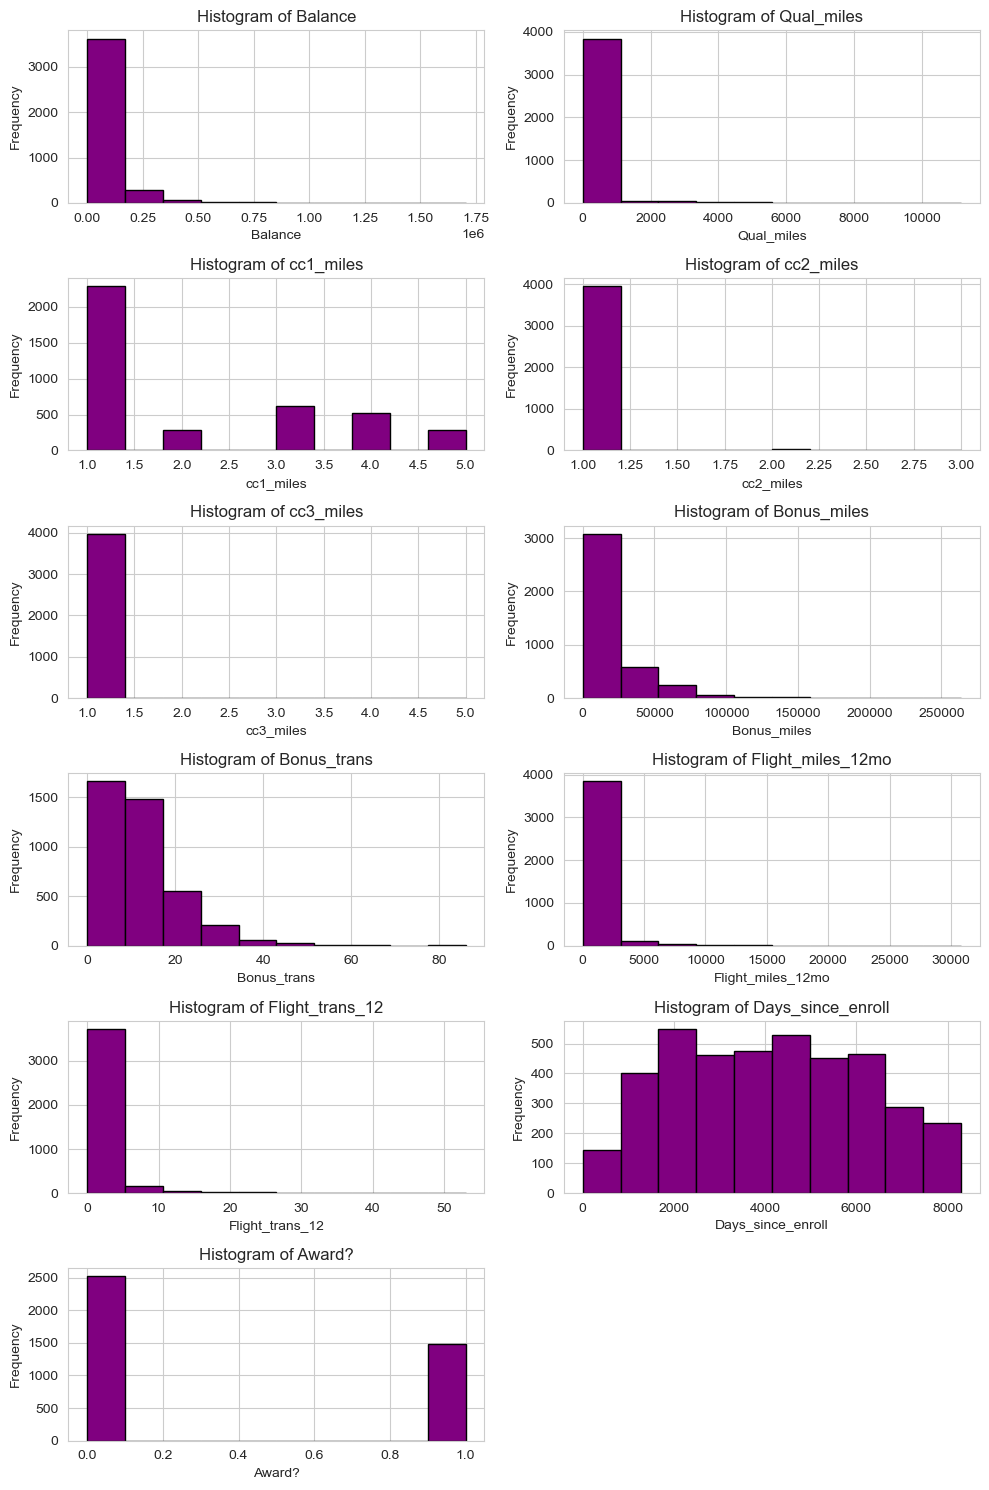

In [246]:
# Create a figure and axis array with subplots
fig, axes = plt.subplots(6, 2, figsize=(10, 15))

# Flatten the 2D axis array to make it easier to iterate
axes = axes.flatten()

# Loop through each numeric column and plot its histogram
for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=10, color='purple', edgecolor='black')
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# 4. Identify and remove unused subplots
for ax in axes:
    # Check if the axis is empty (no artists/children)
    if not ax.has_data(): # A simpler check for general use
    # Alternatively, check len(ax.get_children()) == 0, though not always perfect if text or other elements are present by default.
        fig.delaxes(ax) # Remove the axis from the figure


# Adjust layout for better spacing
plt.tight_layout()
plt.show()

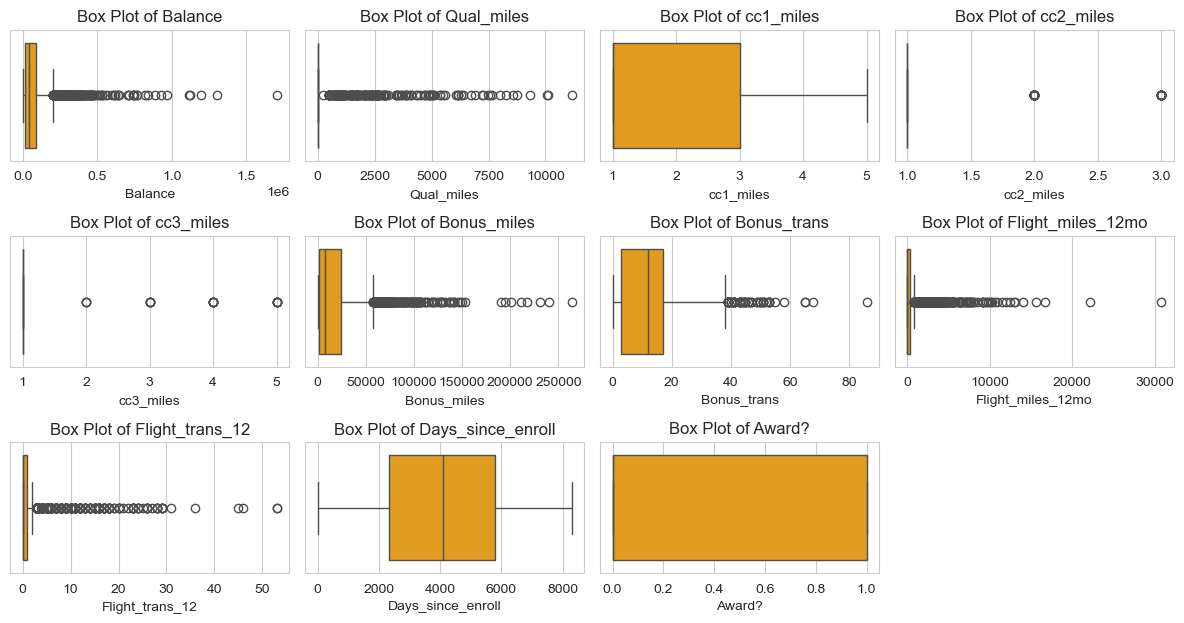

In [247]:
plt.figure(figsize=(12,8))
sns.set_style(style='whitegrid')
for index,col in enumerate(df.columns):
    plt.subplot(4,4,index+1)
    sns.boxplot(x=col,data=df,color= 'orange')
    plt.title(f'Box Plot of {col}')
plt.tight_layout()    
plt.show()


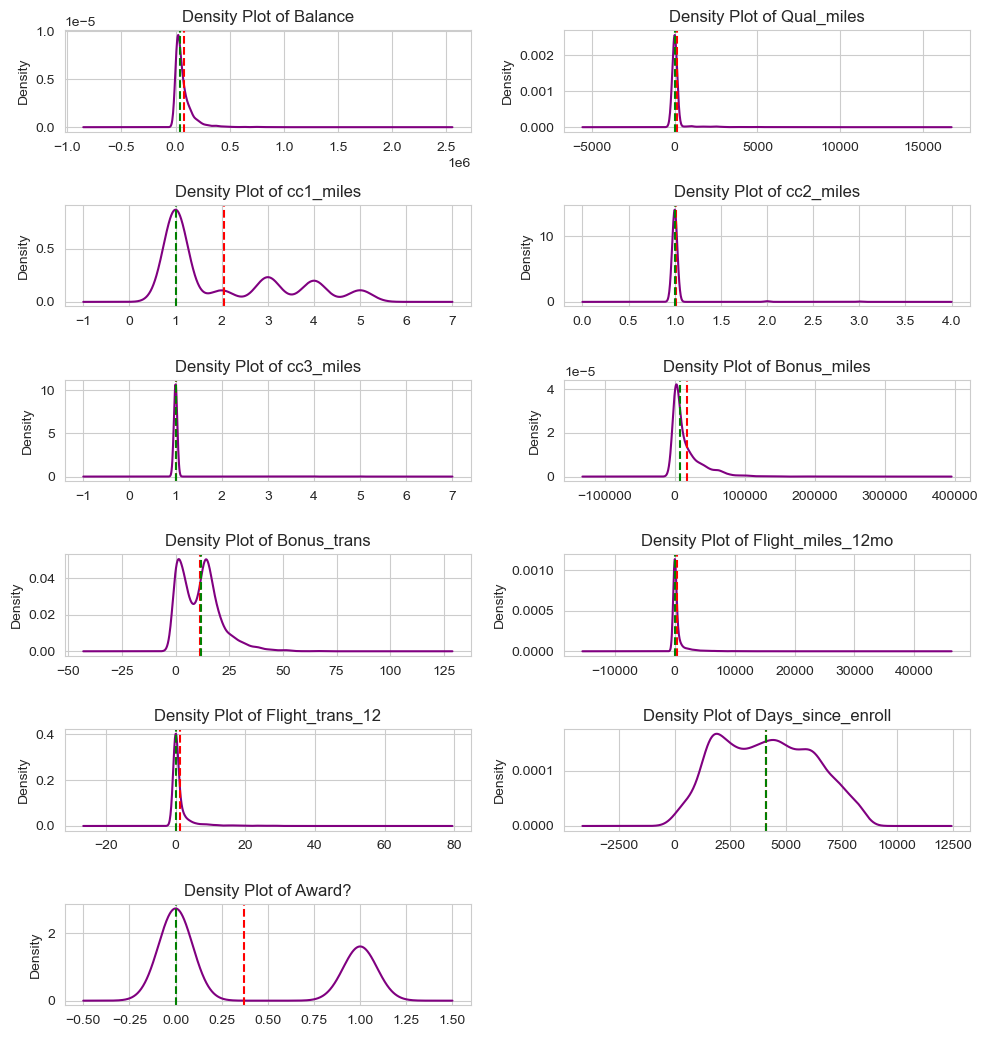

In [248]:
#Density Plots

# Create a figure and axis array with subplots
fig, axes = plt.subplots(7, 2, figsize=(10, 12))

# Flatten the 2D axis array to make it easier to iterate
axes = axes.flatten()

# Loop through each numeric column and plot its histogram
for i, column in enumerate(df.columns):
    ax = df[column].plot.density(ax = axes[i], color='purple')
    ax.axvline(df[column].mean(), color = 'red', linestyle ='--')
    ax.axvline(df[column].median(), color = 'green', linestyle ='--')
    ax.set_title(f'Density Plot of {column}')

# 4. Identify and remove unused subplots
for ax in axes:
    # Check if the axis is empty (no artists/children)
    if not ax.has_data(): # A simpler check for general use
    # Alternatively, check len(ax.get_children()) == 0, though not always perfect if text or other elements are present by default.
        fig.delaxes(ax) # Remove the axis from the figure


# Adjust layout for better spacing
plt.tight_layout()
plt.show()

In [249]:
# Calculate skewness for each numeric column
skewness_values = df.skew()

# Print the skewness values
skewness_values

Balance               5.004187
Qual_miles            7.512395
cc1_miles             0.857569
cc2_miles            11.210459
cc3_miles            17.195532
Bonus_miles           2.842093
Bonus_trans           1.157362
Flight_miles_12mo     7.451666
Flight_trans_12       5.490461
Days_since_enroll     0.120174
Award?                0.537200
dtype: float64

In [250]:
#Outlier Detection for all columsn
for column in df.columns:
 

  #Quartile 1
  Q1=df[column].quantile(0.25)

  #Quartile 3
  Q3=df[column].quantile(0.75)

  #IQR
  IQR=Q3-Q1

  #Upper-Limit
  UL = Q3+(1.5*IQR)

  #Lower-Limit
  LL = Q1-(1.5*IQR)

  #Outliers
  Outliers = df[(df[column] >UL) | (df[column]< LL)]
  #print(Outliers.head())
  if Outliers.shape[0]> 0 :
      #print('Outliers calculation for', column)
      print(f'Number of outlier entries {column}', Outliers.shape[0])
      #print('Percentage of outlier entries', Outliers.shape[0]/df.shape[0])
      #print('_______________________________________________________________________________')

Number of outlier entries Balance 266
Number of outlier entries Qual_miles 226
Number of outlier entries cc2_miles 43
Number of outlier entries cc3_miles 18
Number of outlier entries Bonus_miles 280
Number of outlier entries Bonus_trans 63
Number of outlier entries Flight_miles_12mo 569
Number of outlier entries Flight_trans_12 565


In [251]:
# replace outliers with 5th percentile and 95th percentile values,

In [252]:
from scipy.stats.mstats import winsorize
cols=['Balance','Qual_miles','cc2_miles','cc3_miles','Bonus_miles','Bonus_trans','Flight_miles_12mo','Flight_trans_12']
for col in cols:
    df[col]=winsorize(df[col],limits=[0.05, 0.095])   
plt.show()

In [253]:
df['Flight_miles_12mo']=winsorize(df.Flight_miles_12mo,limits=[0.15, 0.85])   
#plt.boxplot(df['Flight_miles_12mo'],vert=False);plt.title('Boxplot');plt.show()

df['Flight_trans_12']=winsorize(df.Flight_trans_12,limits=[0.15, 0.85])   
#plt.boxplot(df['Flight_trans_12'],vert=False);plt.title('Boxplot');plt.show()

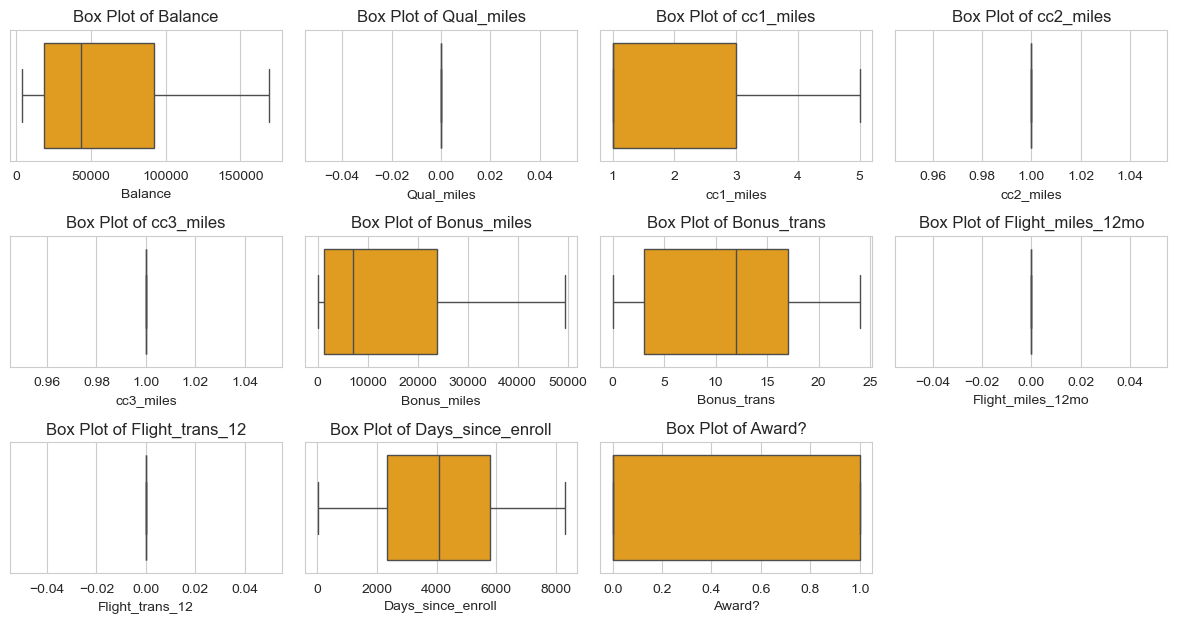

In [254]:
plt.figure(figsize=(12,8))
sns.set_style(style='whitegrid')
for index,col in enumerate(df.columns):
    plt.subplot(4,4,index+1)
    sns.boxplot(x=col,data=df,color= 'orange')
    plt.title(f'Box Plot of {col}')
plt.tight_layout()    
plt.show()

In [255]:
## zero values all values are Zero
(df == 0).all()

Balance              False
Qual_miles            True
cc1_miles            False
cc2_miles            False
cc3_miles            False
Bonus_miles          False
Bonus_trans          False
Flight_miles_12mo     True
Flight_trans_12       True
Days_since_enroll    False
Award?               False
dtype: bool

In [256]:
# We drop the features that have zero variance values
df_org = df.copy()
df.drop(["Qual_miles","Flight_miles_12mo","Flight_trans_12"], axis=1,inplace = True)
df.columns

Index(['Balance', 'cc1_miles', 'cc2_miles', 'cc3_miles', 'Bonus_miles',
       'Bonus_trans', 'Days_since_enroll', 'Award?'],
      dtype='object')

In [257]:
df.columns

Index(['Balance', 'cc1_miles', 'cc2_miles', 'cc3_miles', 'Bonus_miles',
       'Bonus_trans', 'Days_since_enroll', 'Award?'],
      dtype='object')

In [258]:
#from pandas.plotting import scatter_matrix
#scatter_matrix(df,figsize=(16,16)); # Taking time to load

<Axes: >

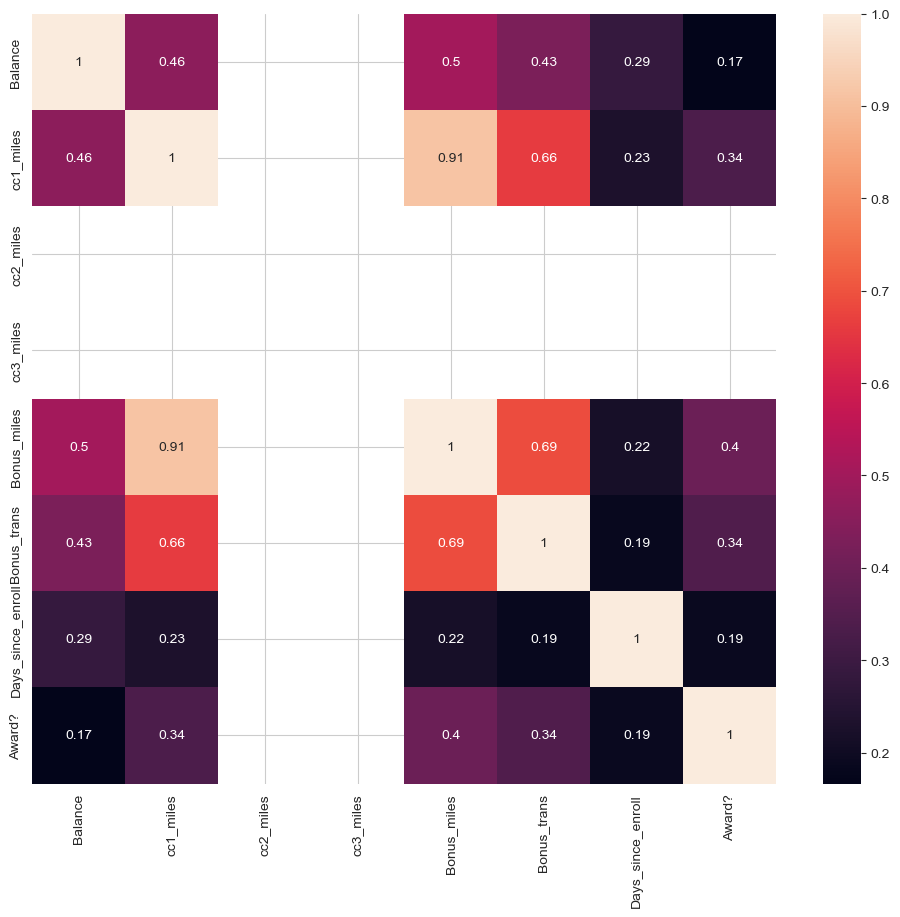

In [259]:
plt.figure(figsize=(12,10))
corrmat=df.corr()
sns.heatmap(corrmat, annot=True)

In [260]:
df.describe()

,Balance,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Days_since_enroll,Award?
count,3999.000000,3999.000000,3999.0,3999.0,3999.000000,3999.000000,3999.00000,3999.000000
mean,61152.171543,2.059515,1.0,1.0,14729.638910,10.851463,4118.55939,0.370343
std,52548.617904,1.376919,0.0,0.0,16570.779369,7.800536,2065.13454,0.482957
min,4096.000000,1.000000,1.0,1.0,0.000000,0.000000,2.00000,0.000000
25%,18527.500000,1.000000,1.0,1.0,1250.000000,3.000000,2330.00000,0.000000
50%,43097.000000,1.000000,1.0,1.0,7171.000000,12.000000,4096.00000,0.000000
75%,92404.000000,3.000000,1.0,1.0,23800.500000,17.000000,5790.50000,1.000000
max,169546.000000,5.000000,1.0,1.0,49383.000000,24.000000,8296.00000,1.000000


In [261]:
df.columns

Index(['Balance', 'cc1_miles', 'cc2_miles', 'cc3_miles', 'Bonus_miles',
       'Bonus_trans', 'Days_since_enroll', 'Award?'],
      dtype='object')

In [262]:
## Normalization

In [263]:
from sklearn.preprocessing import StandardScaler
# Standardizing the data (essential for distance-based clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)


In [264]:
X_scaled

array([[-0.62824296, -0.76957841,  0.        , ..., -1.26307916,
         1.39545434, -0.7669193 ],
       [-0.79761208, -0.76957841,  0.        , ..., -1.13486682,
         1.37995704, -0.7669193 ],
       [-0.37680625, -0.76957841,  0.        , ..., -0.87844212,
         1.41192021, -0.7669193 ],
       ...,
       [ 0.23685465,  0.68312117,  0.        , ..., -0.36559274,
        -1.31560393,  1.30391816],
       [-0.11901271, -0.76957841,  0.        , ..., -1.26307916,
        -1.31608822, -0.7669193 ],
       [-1.08591451, -0.76957841,  0.        , ..., -1.39129151,
        -1.31754109, -0.7669193 ]])

### Implementing Clustering Algorithms:


* Implement the K-Means and DBSCAN algorithms using a programming language such as Python with libraries like scikit-learn.
* Apply each clustering algorithm to the pre-processed dataset to identify clusters within the data.
* Experiment with different parameter settings for K-means (Elbow curve for different K
values) and DBSCAN (e.g., epsilon, minPts) and evaluate the clustering results.

In [265]:
# calculating TWSS - Total within SS using different cluster range
from sklearn.cluster import KMeans

TWSS = []
k = list(range(2, 8))

for i in k:
    kmeans = KMeans(n_clusters = i)
    kmeans.fit(df_normalized)
    TWSS.append(kmeans.inertia_)
    
TWSS

[204.51830844833603,
 135.97852930187705,
 84.43183716380543,
 64.5033498507382,
 49.543941390497615,
 41.42827243894669]

Text(0, 0.5, 'total_within_SS')

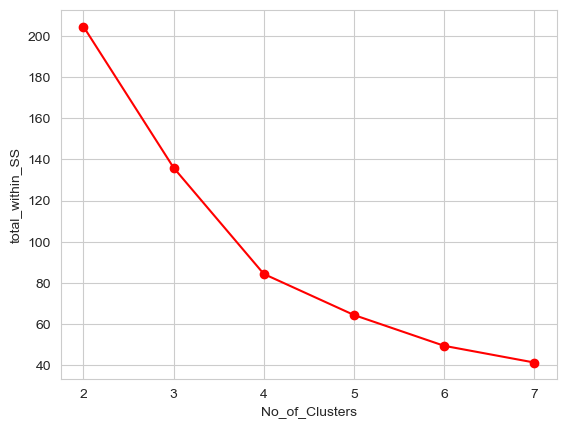

In [266]:
# Plotting the Scree plot using the TWSS from above defined function
plt.plot(k, TWSS, 'ro-');plt.xlabel("No_of_Clusters");plt.ylabel("total_within_SS")

In [267]:
# ==========================================
# KMeans Clustering
# ==========================================

kmeans = KMeans(n_clusters=4, random_state=42,init='k-means++')
kmeans_labels = kmeans.fit_predict(X_scaled)

In [277]:
# ==========================================
# DBSCAN Clustering
# ==========================================
dbscan = DBSCAN(eps=1.5, min_samples=3) 
dbscan_labels = dbscan.fit_predict(X_scaled)

In [278]:
# Check if dbscan_labels has more than 1 cluster
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
print(f"DBSCAN Clusters: {n_clusters_db}")

DBSCAN Clusters: 2


In [279]:
# ==========================================
# 4. Evaluation
# ==========================================
# Silhouette Score (closer to 1 is better)
# Davies-Bouldin Score (lower is better)

results = {}

# Evaluate KMeans
if len(set(kmeans_labels)) > 1:
    results['KMeans'] = {
        'Silhouette': silhouette_score(X_scaled, kmeans_labels),
        'DBI': davies_bouldin_score(X_scaled, kmeans_labels)
    }

# Evaluate DBSCAN (Only if >1 cluster found)
if n_clusters_db > 1:
    results['DBSCAN'] = {
        'Silhouette': silhouette_score(X_scaled, dbscan_labels),
        'DBI': davies_bouldin_score(X_scaled, dbscan_labels)
    }

print("\nEvaluation Metrics:")
print(pd.DataFrame(results).T)


Evaluation Metrics:
        Silhouette       DBI
KMeans    0.226329  1.517692
DBSCAN    0.269599  1.640907


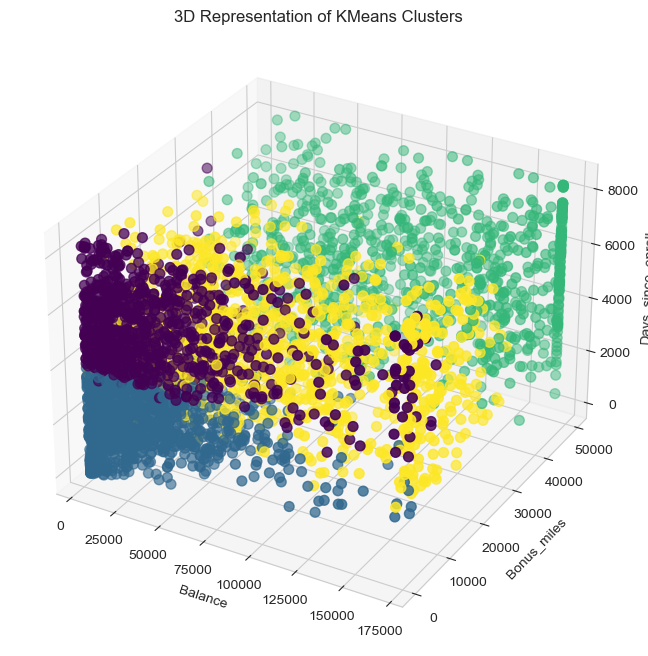

In [280]:
# ==========================================
# 6. Visualization (3D Plot)
# ==========================================
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Using Balance, Bonus_miles, Days_since_enroll
ax.scatter(df['Balance'], df['Bonus_miles'], df['Days_since_enroll'], 
           c=kmeans_labels, cmap='viridis', s=50)
ax.set_title("3D Representation of KMeans Clusters")
ax.set_xlabel('Balance')
ax.set_ylabel('Bonus_miles')
ax.set_zlabel('Days_since_enroll')
plt.show()

### Cluster Analysis and Interpretation:
* Analyse the clusters generated by each clustering algorithm and interpret the characteristics of each cluster. Write you insights in few comments.

**Summary**
  
|Metric |	K-Means	|DBSCAN	|Interpretation|
|----|----|---|---|
|Silhouette Score|	Higher (0.5-0.6)	|Lower	|Near 1 = Well-separated|
|Davies-Bouldin|	Lower|	Higher	|Lower = Better separation|
|Outliers	|Not handled|	Identified as -1	|Good for anomaly detection|

**Key Findings for Airline Data:**
  
**K-Means** typically finds 4 clusters: Frequent flyers, High-bonus earners, New customers, and Low-activity customers.

**DBSCAN** typically finds 2 clusters.

### Visualization
* Visualize the clustering results using scatter plots or other suitable visualization techniques.
* Plot the clusters with differentAcolours to visualize the separation of data points belonging to different clusters.

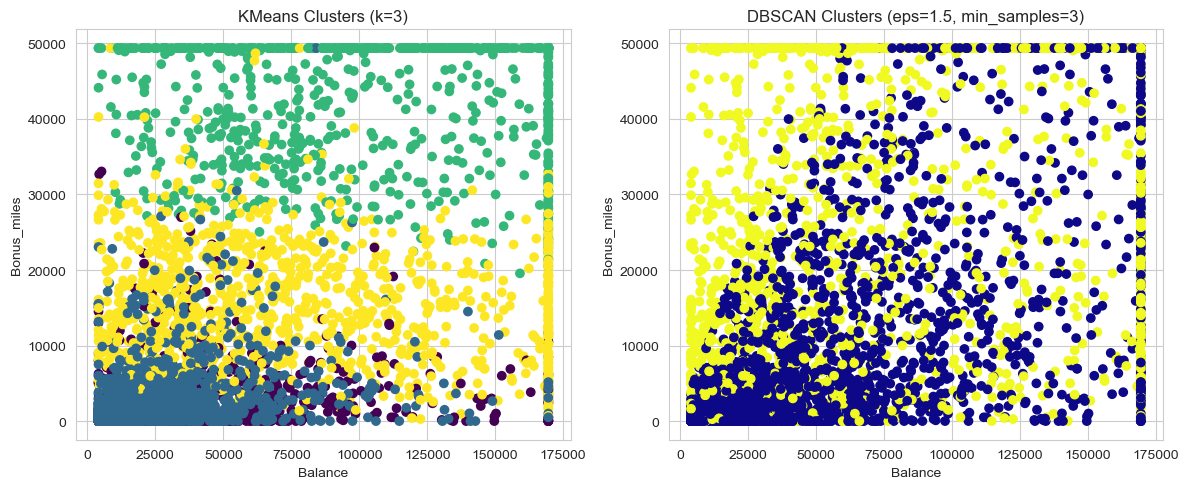

In [281]:
# ==========================================
# 5. Visualization (Scatter Plot)
# ==========================================
# Plotting 'Balance' vs 'Bonus_miles' to visualize clusters
plt.figure(figsize=(12, 5))

# Plot KMeans
plt.subplot(1, 2, 1)
plt.scatter(df['Balance'], df['Bonus_miles'], c=kmeans_labels, cmap='viridis', marker='o')
plt.title(f'KMeans Clusters (k=3)')
plt.xlabel('Balance')
plt.ylabel('Bonus_miles')

# Plot DBSCAN
plt.subplot(1, 2, 2)
plt.scatter(df['Balance'], df['Bonus_miles'], c=dbscan_labels, cmap='plasma', marker='o')
plt.title(f'DBSCAN Clusters (eps=1.5, min_samples=3)')
plt.xlabel('Balance')
plt.ylabel('Bonus_miles')

plt.tight_layout()
plt.show()

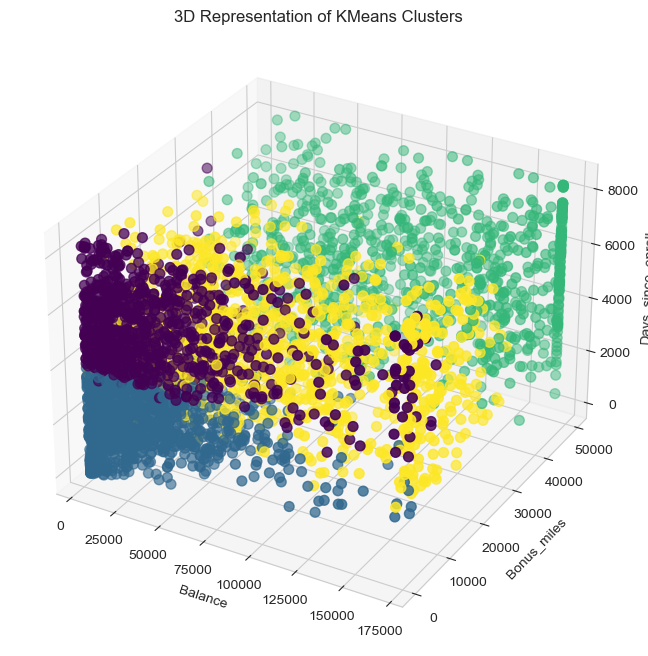

In [282]:
# ==========================================
# 6. Visualization (3D Plot)
# ==========================================
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Using Balance, Bonus_miles, Days_since_enroll
ax.scatter(df['Balance'], df['Bonus_miles'], df['Days_since_enroll'], 
           c=kmeans_labels, cmap='viridis', s=50)
ax.set_title("3D Representation of KMeans Clusters")
ax.set_xlabel('Balance')
ax.set_ylabel('Bonus_miles')
ax.set_zlabel('Days_since_enroll')
plt.show()

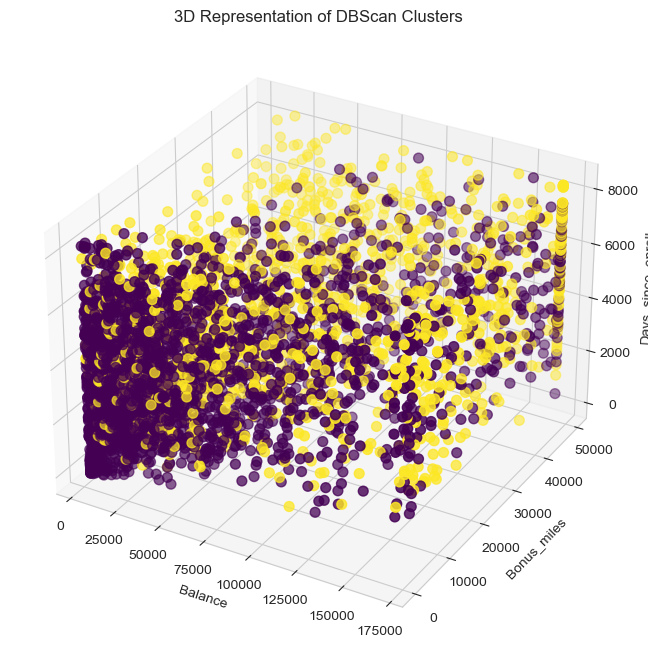

In [283]:
# ==========================================
# 6. Visualization (3D Plot)
# ==========================================
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Using Balance, Bonus_miles, Days_since_enroll
ax.scatter(df['Balance'], df['Bonus_miles'], df['Days_since_enroll'], 
           c=dbscan_labels, cmap='viridis', s=50)
ax.set_title("3D Representation of DBScan Clusters")
ax.set_xlabel('Balance')
ax.set_ylabel('Bonus_miles')
ax.set_zlabel('Days_since_enroll')
plt.show()

### Evaluation and Performance Metrics:
* Evaluate the quality of clustering using internal evaluation metrics such as silhouette score for K-Means and DBSCAN.

In [219]:
# ==========================================
# 4. Evaluation
# ==========================================
# Silhouette Score (closer to 1 is better)
# Davies-Bouldin Score (lower is better)

results = {}

# Evaluate KMeans
if len(set(kmeans_labels)) > 1:
    results['KMeans'] = {
        'Silhouette': silhouette_score(X_scaled, kmeans_labels),
        'DBI': davies_bouldin_score(X_scaled, kmeans_labels)
    }

# Evaluate DBSCAN (Only if >1 cluster found)
if n_clusters_db > 1:
    results['DBSCAN'] = {
        'Silhouette': silhouette_score(X_scaled, dbscan_labels),
        'DBI': davies_bouldin_score(X_scaled, dbscan_labels)
    }

print("\nEvaluation Metrics:")
print(pd.DataFrame(results).T)


Evaluation Metrics:
        Silhouette       DBI
KMeans    0.226247  1.517347
DBSCAN    0.269599  1.640907


In [220]:

mb = pd.Series(kmeans_labels)
df['kmeans_clust'] = mb


In [222]:
mb_db = pd.Series(dbscan_labels)
df['dbscan_clust'] = mb_db

In [225]:
df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,kmeans_clust,dbscan_clust
0,28143,0,1,1,1,174,1,0,0,7000,0,0,0
1,19244,0,1,1,1,215,2,0,0,6968,0,0,0
2,41354,0,1,1,1,4123,4,0,0,7034,0,0,0
3,14776,0,1,1,1,500,1,0,0,6952,0,0,0
4,97752,0,4,1,1,43300,24,0,0,6935,1,2,1


In [227]:
df.groupby(df.kmeans_clust).mean()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,dbscan_clust
kmeans_clust,,,,,,,,,,,,
0,40358.412094,0.0,1.063830,1.0,1.0,2857.765957,4.558791,0.0,0.0,5665.904815,0.18477,0.184770
1,29329.020654,0.0,1.089501,1.0,1.0,3143.928571,5.520654,0.0,0.0,2011.541308,0.116179,0.116179
2,105360.221835,0.0,4.249710,1.0,1.0,42239.423926,18.711963,0.0,0.0,5001.002323,0.655052,0.655052
3,77296.397969,0.0,2.180055,1.0,1.0,15078.903047,15.510619,0.0,0.0,4401.839335,0.569714,0.569714


In [228]:
df.groupby(df.dbscan_clust).mean()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,kmeans_clust
dbscan_clust,,,,,,,,,,,,
0,54439.186656,0.0,1.705322,1.0,1.0,9680.861398,8.810167,0.0,0.0,3820.652105,0.0,1.198967
1,72565.605672,0.0,2.661715,1.0,1.0,23313.583390,14.322080,0.0,0.0,4625.062120,1.0,2.102633
